In [1]:
# ==============================================================================
# CELL 1: Environment Setup & Artifact Download
# ==============================================================================
import os
import requests
import zipfile
import urllib.request
import pandas as pd
import numpy as np

# Install dependencies quietly
!pip install -q ultralytics easyocr git+https://github.com/csebuetnlp/normalizer
!pip install -q google-genai transformers faiss-cpu pandas numpy torch opencv-python
# Add this line at the top of CELL 1
!apt-get install -y zbar-tools libzbar0
!pip install -q pyzbar

WORKING_DIR = "/kaggle/working" if os.path.exists("/kaggle") else "./"
WEIGHTS_PATH = os.path.join(WORKING_DIR, "rtdetr_best.pt")
ZIP_PATH = os.path.join(WORKING_DIR, "Photocard-fake-real-classification.zip")
EXTRACT_DIR = os.path.join(WORKING_DIR, "dataset_classification_raw")

CSV_FILENAME = "structured_extracted_claims_ocr.csv"
LOCAL_CSV_PATH = os.path.join(WORKING_DIR, CSV_FILENAME)

REMOTE_CACHE_URL = f"https://storage.saifullahmnsur.dev/download/{CSV_FILENAME}"
UPLOAD_ENDPOINT = "https://storage.saifullahmnsur.dev/upload"

RTDETR_WEIGHTS_URL = "https://storage.saifullahmnsur.dev/download/rtdetr_complete_artifacts/models/rtdetr_best.pt"
DATASET_URL = "https://storage.saifullahmnsur.dev/download/Photocard-fake-real-classification.zip"

def push_to_server(file_path):
    """Pushes local CSV/ZIP artifacts to the remote storage server."""
    try:
        filename = os.path.basename(file_path)
        print(f"[*] Uploading '{filename}' to storage server ({UPLOAD_ENDPOINT})...")
        with open(file_path, 'rb') as f:
            files = {'file': (filename, f, 'application/octet-stream')}
            response = requests.post(UPLOAD_ENDPOINT, files=files, timeout=120)
            if response.status_code in [200, 201]:
                print(f"[★] Successfully uploaded '{filename}' to storage server!")
            else:
                print(f"[!] Upload failed with server status code: {response.status_code}")
    except Exception as e:
        print(f"[!] Server upload exception: {e}")

# Check local or remote cache
df_claims = None

if os.path.exists(LOCAL_CSV_PATH) and os.path.getsize(LOCAL_CSV_PATH) > 0:
    print(f"[+] Loaded existing local structured OCR cache.")
    df_claims = pd.read_csv(LOCAL_CSV_PATH).fillna("")
else:
    print(f"[*] Checking remote storage server for cached OCR data: {REMOTE_CACHE_URL}")
    try:
        res = requests.get(REMOTE_CACHE_URL, stream=True, timeout=10)
        if res.status_code == 200 and int(res.headers.get('content-length', 1)) > 0:
            with open(LOCAL_CSV_PATH, "wb") as f:
                for chunk in res.iter_content(chunk_size=8192):
                    f.write(chunk)
            df_claims = pd.read_csv(LOCAL_CSV_PATH).fillna("")
            print(f"[★] Downloaded structured OCR cache ({len(df_claims)} records).")
        else:
            print(f"[*] Remote cache missing (HTTP {res.status_code}). Preparing resources...")
    except Exception as e:
        print(f"[!] Unable to connect to remote cache server: {e}. Preparing resources...")

# Download model weights & dataset zip if OCR run is required
if df_claims is None:
    if not os.path.exists(WEIGHTS_PATH):
        print(f"[*] Downloading trained RT-DETR weights from {RTDETR_WEIGHTS_URL}...")
        urllib.request.urlretrieve(RTDETR_WEIGHTS_URL, WEIGHTS_PATH)

    if not os.path.exists(ZIP_PATH):
        print(f"[*] Downloading photocard dataset from {DATASET_URL}...")
        urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    if not os.path.exists(EXTRACT_DIR):
        print(f"[*] Extracting dataset zip...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)

print("[★] Environment initialized successfully!")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.8 MB/s eta 0:00:00:00:0100:01
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libv4l-0 libv4lconvert0
Suggested packages:
  zbarcam-gtk zbarcam-qt
The following NEW packages will be installed:
  libv4l-0 libv4lconvert0 libzbar0 zbar-tools
0 upgraded, 4 newly installed, 0 to remove and 124 not upgraded.
Need to get 271 kB of archives.
After this operation, 930 kB of additional disk space 

In [2]:
# ==============================================================================
# CELL 2: Initialize RT-DETR/EasyOCR & Stratified Sampling (100 Fake / 100 Real)
# ==============================================================================
import torch
import easyocr
import glob
import random
from ultralytics import RTDETR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Execution Device: {device}")

CLASS_NAMES = {
    0: 'publisher', 1: 'publisher_logo', 2: 'image', 3: 'headline',
    4: 'text', 5: 'date', 6: 'url', 7: 'ad', 8: 'photocard',
    9: 'qr_code', 10: 'speaker'
}

sampled_image_paths = []

if df_claims is None:
    print(f"[*] Loading fine-tuned RT-DETR model from '{WEIGHTS_PATH}'...")
    rtdetr_model = RTDETR(WEIGHTS_PATH)

    print("[*] Initializing EasyOCR Engine (Bangla + English)...")
    ocr_reader = easyocr.Reader(['bn', 'en'], gpu=torch.cuda.is_available())

    # Collect images
    all_images = sorted(
        glob.glob(f"{EXTRACT_DIR}/**/*.jpg", recursive=True) +
        glob.glob(f"{EXTRACT_DIR}/**/*.png", recursive=True) +
        glob.glob(f"{EXTRACT_DIR}/**/*.jpeg", recursive=True)
    )

    fake_images = [img for img in all_images if 'fake' in img.lower()]
    real_images = [img for img in all_images if 'fake' not in img.lower()]

    # Set seed for reproducible random sampling
    random.seed(42)
    sampled_fake = random.sample(fake_images, min(100, len(fake_images)))
    sampled_real = random.sample(real_images, min(100, len(real_images)))

    sampled_image_paths = sampled_fake + sampled_real
    random.shuffle(sampled_image_paths)

    print(f"[★] Sampled {len(sampled_fake)} Fake and {len(sampled_real)} Real images (Total: {len(sampled_image_paths)})")
else:
    rtdetr_model = None
    ocr_reader = None
    print("[+] Using pre-computed structured OCR cache. Model loading skipped!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[*] Execution Device: cuda
[*] Loading fine-tuned RT-DETR model from '/kaggle/working/rtdetr_best.pt'...
[*] Initializing EasyOCR Engine (Bangla + English)...


Progress: |██████████████████████████████████████████████████| 100.0% Complete[★] Sampled 100 Fake and 100 Real images (Total: 200)


In [3]:
# ==============================================================================
# CELL 3: Crop Storage, QR Payload Fetching, Structured OCR & Server Push
# ==============================================================================
import cv2
import json
import shutil
from pyzbar.pyzbar import decode as parse_qr_pyzbar

DETECTION_OUTPUT_DIR = os.path.join(WORKING_DIR, "detection_output")
os.makedirs(DETECTION_OUTPUT_DIR, exist_ok=True)

def decode_qr_code(image_crop):
    """
    Decodes QR code data using pyzbar with OpenCV fallback.
    """
    if image_crop is None or image_crop.size == 0:
        return ""
    
    # Method 1: pyzbar
    try:
        qr_objects = parse_qr_pyzbar(image_crop)
        for obj in qr_objects:
            qr_text = obj.data.decode('utf-8').strip()
            if qr_text:
                return qr_text
    except Exception:
        pass

    # Method 2: OpenCV QRCodeDetector Fallback
    try:
        detector = cv2.QRCodeDetector()
        data, bbox, _ = detector.detectAndDecode(image_crop)
        if data and data.strip():
            return data.strip()
    except Exception:
        pass

    return ""

def process_and_crop_image(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    img_h, img_w, _ = img_bgr.shape
    results = rtdetr_model(img_bgr, conf=0.25, verbose=False)[0]

    image_name_raw = os.path.basename(image_path)
    folder_name = os.path.splitext(image_name_raw)[0]
    img_output_dir = os.path.join(DETECTION_OUTPUT_DIR, folder_name)
    os.makedirs(img_output_dir, exist_ok=True)

    structured_data = {
        "headline": [], "speaker": [], "publisher": [],
        "date": [], "body_text": [], "url": [], "ad": [], "qr_data": []
    }
    region_metadata = []

    # Check whole frame for QR codes
    full_img_qr = decode_qr_code(img_bgr)
    if full_img_qr:
        structured_data["qr_data"].append(full_img_qr)

    for idx, box in enumerate(results.boxes):
        cls_id = int(box.cls[0].item())
        class_name = CLASS_NAMES.get(cls_id, f"class_{cls_id}")
        conf_score = float(box.conf[0].item())
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        pad = 5
        crop = img_bgr[max(0, y1 - pad):min(img_h, y2 + pad), max(0, x1 - pad):min(img_w, x2 + pad)]

        extracted_text = ""
        crop_filename = ""

        if crop.size > 0:
            crop_filename = f"{class_name}_{idx}.jpg"
            crop_path = os.path.join(img_output_dir, crop_filename)
            cv2.imwrite(crop_path, crop)

            # Decode QR code if component is qr_code
            if class_name == 'qr_code':
                qr_content = decode_qr_code(crop)
                if qr_content:
                    structured_data["qr_data"].append(qr_content)
                    extracted_text = f"[QR Payload: {qr_content}]"

            # EasyOCR for text components
            if not extracted_text:
                ocr_res = ocr_reader.readtext(crop)
                extracted_text = " ".join([txt for _, txt, _ in ocr_res]).strip()

        if extracted_text:
            if class_name == 'headline':
                structured_data["headline"].append(extracted_text)
            elif class_name == 'speaker':
                structured_data["speaker"].append(extracted_text)
            elif class_name in ['publisher', 'publisher_logo']:
                structured_data["publisher"].append(extracted_text)
            elif class_name == 'date':
                structured_data["date"].append(extracted_text)
            elif class_name == 'text':
                structured_data["body_text"].append(extracted_text)
            elif class_name == 'url':
                structured_data["url"].append(extracted_text)
            elif class_name == 'ad':
                structured_data["ad"].append(extracted_text)

        region_metadata.append({
            "region_id": idx,
            "class_id": cls_id,
            "label_name": class_name,
            "confidence": round(conf_score, 4),
            "bbox": [x1, y1, x2, y2],
            "cropped_file": crop_filename,
            "extracted_text": extracted_text
        })

    with open(os.path.join(img_output_dir, "regions_metadata.json"), "w", encoding="utf-8") as f:
        json.dump(region_metadata, f, ensure_ascii=False, indent=2)

    return {
        "image_name": image_name_raw,
        "image_path": image_path,
        "label": 0 if 'fake' in image_path.lower() else 1,
        "headline": " ".join(structured_data["headline"]).strip(),
        "speaker": " ".join(structured_data["speaker"]).strip(),
        "publisher": " ".join(structured_data["publisher"]).strip(),
        "date": " ".join(structured_data["date"]).strip(),
        "body_text": " ".join(structured_data["body_text"]).strip(),
        "url": " ".join(structured_data["url"]).strip(),
        "qr_data": " | ".join(list(set(structured_data["qr_data"]))).strip(),
        "ad": " ".join(structured_data["ad"]).strip()
    }

# Execute OCR or load cached DataFrame
if df_claims is None:
    print(f"[*] Processing components & cropping for {len(sampled_image_paths)} sampled images...")
    extracted_rows = []
    
    for idx, path in enumerate(sampled_image_paths):
        row_data = process_and_crop_image(path)
        if row_data:
            extracted_rows.append(row_data)

        if (idx + 1) % 10 == 0 or (idx + 1) == len(sampled_image_paths):
            print(f"  [+] Cropped & extracted text/QR for {idx + 1}/{len(sampled_image_paths)} images")

    df_claims = pd.DataFrame(extracted_rows)
    df_claims.to_csv(LOCAL_CSV_PATH, index=False)
    print(f"[+] Saved structured OCR & QR dataset locally: '{LOCAL_CSV_PATH}'")

    # Zip cropped detection output directory and upload to server
    CROP_ZIP_PATH = os.path.join(WORKING_DIR, "detection_output_cropped.zip")
    print(f"[*] Zipping detection output directory into '{CROP_ZIP_PATH}'...")
    shutil.make_archive(CROP_ZIP_PATH.replace('.zip', ''), 'zip', DETECTION_OUTPUT_DIR)
    
    push_to_server(CROP_ZIP_PATH)
    push_to_server(LOCAL_CSV_PATH)
else:
    print("[★] Using pre-computed structured OCR dataset. Ensuring missing schema columns...")
    # Safe guard: Ensure all expected columns exist even if loaded from older CSV
    for col in ['headline', 'publisher', 'speaker', 'date', 'url', 'qr_data', 'body_text']:
        if col not in df_claims.columns:
            df_claims[col] = ""

print("\n[★] Structured Sample Output Preview (with QR Data):")
preview_cols = [c for c in ['image_name', 'publisher', 'speaker', 'headline', 'qr_data', 'url'] if c in df_claims.columns]
print(df_claims[preview_cols].head(5))

[*] Processing components & cropping for 200 sampled images...
  [+] Cropped & extracted text/QR for 10/200 images
  [+] Cropped & extracted text/QR for 20/200 images
  [+] Cropped & extracted text/QR for 30/200 images
  [+] Cropped & extracted text/QR for 40/200 images
  [+] Cropped & extracted text/QR for 50/200 images
  [+] Cropped & extracted text/QR for 60/200 images
  [+] Cropped & extracted text/QR for 70/200 images
  [+] Cropped & extracted text/QR for 80/200 images
  [+] Cropped & extracted text/QR for 90/200 images
  [+] Cropped & extracted text/QR for 100/200 images
  [+] Cropped & extracted text/QR for 110/200 images
  [+] Cropped & extracted text/QR for 120/200 images
  [+] Cropped & extracted text/QR for 130/200 images
  [+] Cropped & extracted text/QR for 140/200 images
  [+] Cropped & extracted text/QR for 150/200 images
  [+] Cropped & extracted text/QR for 160/200 images
  [+] Cropped & extracted text/QR for 170/200 images
  [+] Cropped & extracted text/QR for 180/200

In [4]:
# ==============================================================================
# CELL 4: Initialize BanglaBERT Encoder & Grounded GenAI Client
# ==============================================================================
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from normalizer import normalize
from google import genai

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Execution Device: {device}")

# Load Pretrained BanglaBERT Model
BANGLA_BERT_MODEL = "csebuetnlp/banglabert"
print(f"[*] Loading BanglaBERT model: '{BANGLA_BERT_MODEL}'...")

bert_tokenizer = AutoTokenizer.from_pretrained(BANGLA_BERT_MODEL)
bert_model = AutoModel.from_pretrained(BANGLA_BERT_MODEL).to(device)
bert_model.eval()

def encode_headline_vector(text: str) -> np.ndarray:
    norm_text = normalize(str(text)) if str(text).strip() else ""
    if not norm_text:
        return np.zeros(768, dtype=np.float32)
    
    inputs = bert_tokenizer(
        norm_text, return_tensors="pt", truncation=True, max_length=128, padding=True
    ).to(device)
    
    with torch.no_grad():
        outputs = bert_model(**inputs)
        vec = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        
    return vec.astype(np.float32)

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GEMINI_API_KEY = user_secrets.get_secret("GEMINI_API_KEY")
# GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "YOUR_GEMINI_API_KEY")
genai_client = genai.Client(api_key=GEMINI_API_KEY)

print("[+] BanglaBERT Vector Encoder & GenAI Grounded Client Ready!")

[*] Execution Device: cuda
[*] Loading BanglaBERT model: 'csebuetnlp/banglabert'...


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
electra.embeddings.position_ids                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

[+] BanglaBERT Vector Encoder & GenAI Grounded Client Ready!


In [6]:
# ==============================================================================
# CELL 5: Encode Headlines via BanglaBERT & Index in FAISS
# ==============================================================================
import faiss

print("[*] Normalizing headlines & generating 768-dim dense vector matrix...")

df_claims['norm_headline'] = df_claims['headline'].apply(
    lambda x: normalize(str(x)) if str(x).strip() else ""
)

vector_list = [encode_headline_vector(h) for h in df_claims['norm_headline']]
headline_embeddings = np.array(vector_list, dtype=np.float32)

faiss_embeddings = headline_embeddings.copy()
faiss.normalize_L2(faiss_embeddings)

index = faiss.IndexFlatIP(768)
index.add(faiss_embeddings)

print(f"[★] Tier 1 FAISS Index built with {index.ntotal} BanglaBERT vectors.")

[*] Normalizing headlines & generating 768-dim dense vector matrix...
[★] Tier 1 FAISS Index built with 200 BanglaBERT vectors.


In [7]:
# ==============================================================================
# CELL 6: Two-Tier Fact Verification (Outputs: is_factual, confidence_score, verdict)
# ==============================================================================
import json
from google.genai import types

def verify_factual_truth(row: pd.Series, self_index: int = None) -> dict:
    headline_str = str(row.get('headline', ''))
    publisher_str = str(row.get('publisher', ''))
    speaker_str = str(row.get('speaker', ''))
    date_str = str(row.get('date', ''))
    norm_headline = normalize(headline_str) if headline_str.strip() else ""

    if not norm_headline or len(norm_headline) < 5:
        return {
            "verdict": "FAKE",
            "is_factual": False,
            "confidence_score": 0.0,
            "tier_used": "Tier 0 (Invalid)"
        }

    # TIER 1: Local FAISS Search (BanglaBERT Vector Space)
    query_vec = encode_headline_vector(norm_headline).reshape(1, -1)
    faiss.normalize_L2(query_vec)
    
    similarities, indices = index.search(query_vec, k=2)
    top_sim = 0.0
    for sim, idx in zip(similarities[0], indices[0]):
        if self_index is not None and idx == self_index:
            continue
        top_sim = float(sim)
        break

    if top_sim >= 0.85:
        return {
            "verdict": "REAL",
            "is_factual": True,
            "confidence_score": round(top_sim, 4),
            "tier_used": "Tier 1 (FAISS Local)"
        }

    # TIER 2: Grounded Gemini Live Search Fallback
    prompt = f"""
Act as an automated factual verification engine for Bangladeshi media and news photocards.
Determine if the following claim is Factually True (REAL) or Factually False/Unverified (FAKE) by searching live web coverage.

Claim Details:
- Cited Publisher: {publisher_str if publisher_str else 'N/A'}
- Cited Speaker: {speaker_str if speaker_str else 'N/A'}
- Date on Card: {date_str if date_str else 'N/A'}
- Headline: "{norm_headline}"

Task:
1. Search live web sources for matching verified news reporting from Bangladeshi news outlets.
2. Respond STRICTLY in valid JSON format with keys:
   - "verdict": "REAL" or "FAKE"
   - "confidence_score": float between 0.0 and 1.0
"""

    try:
        response = genai_client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt,
            config=types.GenerateContentConfig(
                tools=[types.Tool(google_search=types.GoogleSearch())],
                temperature=0.1
            )
        )
        
        clean_text = response.text.replace("```json", "").replace("```", "").strip()
        parsed = json.loads(clean_text)
        
        verdict = parsed.get("verdict", "FAKE").upper()
        is_factual = (verdict == "REAL")
        confidence = float(parsed.get("confidence_score", 0.5))

        return {
            "verdict": verdict,
            "is_factual": is_factual,
            "confidence_score": round(confidence, 4),
            "tier_used": "Tier 2 (Grounded Gemini)"
        }

    except Exception:
        is_factual = (top_sim >= 0.50)
        return {
            "verdict": "REAL" if is_factual else "FAKE",
            "is_factual": is_factual,
            "confidence_score": round(top_sim, 4),
            "tier_used": "Tier 1 Fallback (API Offline)"
        }

print("[*] Running factual verification on sampled dataset...")

results = []
for idx, row in df_claims.iterrows():
    res = verify_factual_truth(row, self_index=idx)
    results.append(res)
    
    if (idx + 1) % 20 == 0 or (idx + 1) == len(df_claims):
        print(f"  [+] Fact-checked {idx + 1}/{len(df_claims)} claims")

df_results = pd.DataFrame(results)
df_factual_output = pd.concat([df_claims[['image_name', 'publisher', 'speaker', 'headline', 'label']], df_results], axis=1)

print("\n[★] Factual Verdict Distribution:")
print(df_factual_output['verdict'].value_counts())

# Save and upload final verified output
FINAL_CSV = os.path.join(WORKING_DIR, "factual_verification_results.csv")
df_factual_output.to_csv(FINAL_CSV, index=False)
push_to_server(FINAL_CSV)

print("\n[★] Verified Results Sample:")
print(df_factual_output[['image_name', 'headline', 'is_factual', 'confidence_score', 'verdict']].head(5))

[*] Running factual verification on sampled dataset...
  [+] Fact-checked 20/200 claims
  [+] Fact-checked 40/200 claims
  [+] Fact-checked 60/200 claims
  [+] Fact-checked 80/200 claims
  [+] Fact-checked 100/200 claims
  [+] Fact-checked 120/200 claims
  [+] Fact-checked 140/200 claims
  [+] Fact-checked 160/200 claims
  [+] Fact-checked 180/200 claims
  [+] Fact-checked 200/200 claims

[★] Factual Verdict Distribution:
verdict
REAL    196
FAKE      4
Name: count, dtype: int64
[*] Uploading 'factual_verification_results.csv' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'factual_verification_results.csv' to storage server!

[★] Verified Results Sample:
                                          image_name  \
0                                  BS_02_SPT_049.jpg   
1                                  KK_01_ENT_190.jpg   
2  facebook-phase-1_is_photocard_0299_sciencebeep...   
3                                  XX_03_POL_103.jpg   
4           

In [11]:
# ==============================================================================
# CELL 6: Fixed Multi-Component Fact Verification
# ==============================================================================
import json
from google.genai import types

def verify_factual_truth(row: pd.Series, row_idx: int) -> dict:
    headline_str = str(row.get('headline', ''))
    publisher_str = str(row.get('publisher', ''))
    speaker_str = str(row.get('speaker', ''))
    date_str = str(row.get('date', ''))
    url_str = str(row.get('url', ''))
    qr_data_str = str(row.get('qr_data', ''))
    
    norm_headline = normalize(headline_str) if headline_str.strip() else ""

    # Invalid or short headline -> Default to FAKE
    if not norm_headline or len(norm_headline) < 5:
        return {
            "verdict": "FAKE",
            "is_factual": False,
            "confidence_score": 0.0,
            "tier_used": "Tier 0 (Invalid)",
            "qr_alignment_boost": False
        }

    # --------------------------------------------------------------------------
    # TIER 1: FAISS Search (Strictly Exclude Self-Match)
    # --------------------------------------------------------------------------
    query_vec = encode_headline_vector(norm_headline).reshape(1, -1)
    faiss.normalize_L2(query_vec)
    
    similarities, indices = index.search(query_vec, k=5)
    
    top_sim = 0.0
    for sim, neighbor_idx in zip(similarities[0], indices[0]):
        # CRITICAL FIX: Skip exact self-index match
        if neighbor_idx == row_idx:
            continue
        top_sim = float(sim)
        break # Take highest non-self similarity match

    # High Local Match Threshold against OTHER indexed verified news
    if top_sim >= 0.85:
        return {
            "verdict": "REAL",
            "is_factual": True,
            "confidence_score": round(top_sim, 4),
            "tier_used": "Tier 1 (FAISS Local)",
            "qr_alignment_boost": False
        }

    # --------------------------------------------------------------------------
    # TIER 2: Live Web Search Grounding (Gemini)
    # --------------------------------------------------------------------------
    prompt = f"""
Act as an automated factual verification engine for Bangladeshi media and news photocards.
Determine if the following photocard assertion is Factually True (REAL) or Factually False/Fake (FAKE) by searching live news coverage.

Claim Details:
- Headline: "{norm_headline}"
- Cited Publisher: {publisher_str if publisher_str else 'N/A'}
- Cited Speaker: {speaker_str if speaker_str else 'N/A'}
- Date on Card: {date_str if date_str else 'N/A'}
- Embedded URL(s): {url_str if url_str else 'N/A'}
- Decoded QR Code Payload: {qr_data_str if qr_data_str else 'N/A'}

Instructions:
1. Search live web sources (e.g., Prothom Alo, The Daily Star, Samakal, Somoy TV, Jamuna TV, BDNews24, Rumor Scanner, FactWatch) for official reporting matching this headline and speaker quote.
2. If the headline is fabricated, made-up, or misattributed to the publisher/speaker, verdict MUST be FAKE.
3. Respond STRICTLY in valid JSON format with keys:
   - "verdict": "REAL" or "FAKE"
   - "confidence_score": float between 0.0 and 1.0
   - "qr_aligned": boolean
"""

    try:
        response = genai_client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt,
            config=types.GenerateContentConfig(
                tools=[types.Tool(google_search=types.GoogleSearch())],
                temperature=0.1
            )
        )
        
        clean_text = response.text.replace("```json", "").replace("```", "").strip()
        parsed = json.loads(clean_text)
        
        verdict = str(parsed.get("verdict", "FAKE")).upper()
        is_factual = (verdict == "REAL")
        confidence = float(parsed.get("confidence_score", 0.5))
        qr_boost = bool(parsed.get("qr_aligned", False))

        return {
            "verdict": verdict,
            "is_factual": is_factual,
            "confidence_score": round(confidence, 4),
            "tier_used": "Tier 2 (Grounded Gemini)",
            "qr_alignment_boost": qr_boost
        }

    except Exception as e:
        is_factual = (top_sim >= 0.50)
        return {
            "verdict": "REAL" if is_factual else "FAKE",
            "is_factual": is_factual,
            "confidence_score": round(top_sim, 4),
            "tier_used": "Tier 1 Fallback (API Offline)",
            "qr_alignment_boost": False
        }

print("[*] Running corrected factual verification on dataset...")

results = []
for idx, row in df_claims.iterrows():
    res = verify_factual_truth(row, row_idx=idx)
    results.append(res)
    
    if (idx + 1) % 10 == 0 or (idx + 1) == len(df_claims):
        print(f"  [+] Fact-checked {idx + 1}/{len(df_claims)} claims")

df_results = pd.DataFrame(results)
df_factual_output = pd.concat([df_claims.reset_index(drop=True), df_results.reset_index(drop=True)], axis=1)

print("\n[★] Tier Used Breakdown:")
print(df_factual_output['tier_used'].value_counts())

print("\n[★] Corrected Verdict Distribution:")
print(df_factual_output['verdict'].value_counts())

[*] Running corrected factual verification on dataset...
  [+] Fact-checked 10/200 claims
  [+] Fact-checked 20/200 claims
  [+] Fact-checked 30/200 claims
  [+] Fact-checked 40/200 claims
  [+] Fact-checked 50/200 claims
  [+] Fact-checked 60/200 claims
  [+] Fact-checked 70/200 claims
  [+] Fact-checked 80/200 claims
  [+] Fact-checked 90/200 claims
  [+] Fact-checked 100/200 claims
  [+] Fact-checked 110/200 claims
  [+] Fact-checked 120/200 claims
  [+] Fact-checked 130/200 claims
  [+] Fact-checked 140/200 claims
  [+] Fact-checked 150/200 claims
  [+] Fact-checked 160/200 claims
  [+] Fact-checked 170/200 claims
  [+] Fact-checked 180/200 claims
  [+] Fact-checked 190/200 claims
  [+] Fact-checked 200/200 claims

[★] Tier Used Breakdown:
tier_used
Tier 1 (FAISS Local)    196
Tier 0 (Invalid)          4
Name: count, dtype: int64

[★] Corrected Verdict Distribution:
verdict
REAL    196
FAKE      4
Name: count, dtype: int64


             STREAM 2 FACTUAL VERIFICATION EVALUATION REPORT             
  Overall Classification Accuracy : 49.00%
  Precision                       : 0.4949
  Recall                          : 0.9700
  F1-Score                        : 0.6554
-----------------------------------------------------------------

Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.25      0.01      0.02       100
    Real (1)       0.49      0.97      0.66       100

    accuracy                           0.49       200
   macro avg       0.37      0.49      0.34       200
weighted avg       0.37      0.49      0.34       200

[*] Uploading 'factual_performance_metrics.csv' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'factual_performance_metrics.csv' to storage server!


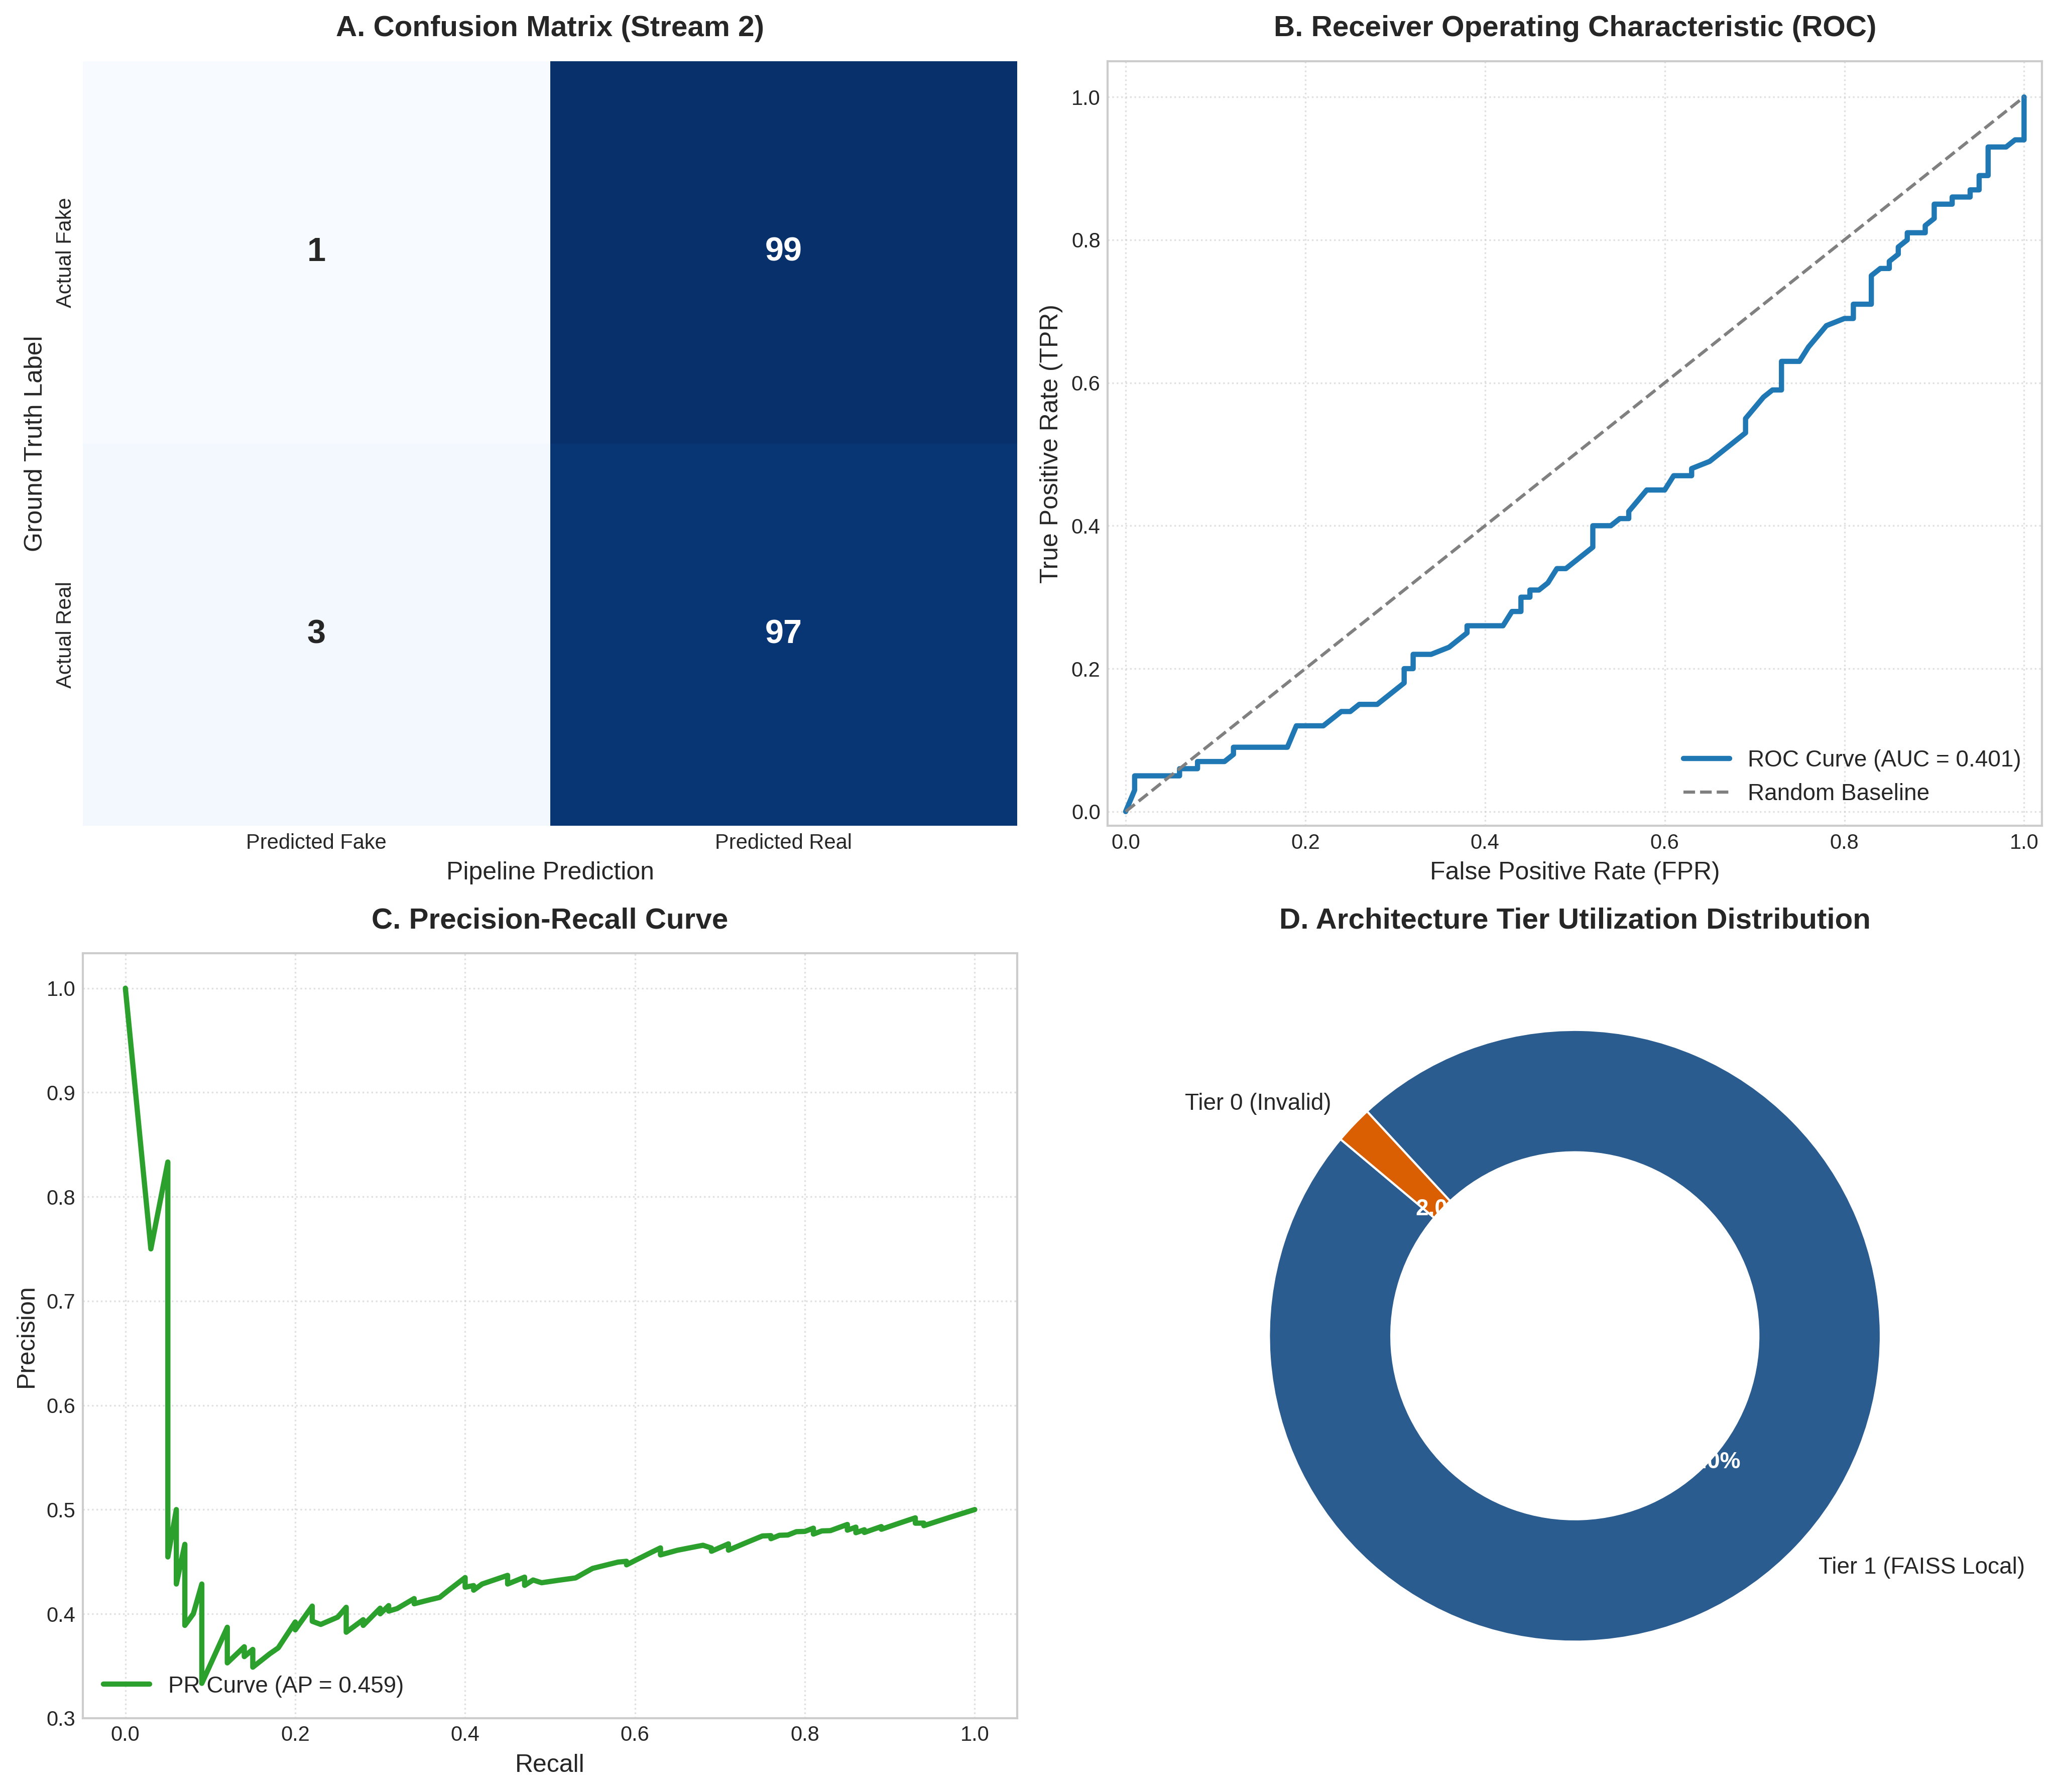

[+] Saved performance plot figure to: '/kaggle/working/factual_performance_analysis.png'
[*] Uploading 'factual_performance_analysis.png' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'factual_performance_analysis.png' to storage server!


In [12]:
# ==============================================================================
# CELL 7: Export Performance Data & Visual Performance Analysis
# ==============================================================================
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Configure plot formatting for publications
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig_output_dir = os.path.join(WORKING_DIR, "performance_visualizations")
os.makedirs(fig_output_dir, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. COMPUTE NUMERICAL EVALUATION METRICS
# ------------------------------------------------------------------------------
y_true = df_factual_output['label'].astype(int).values  # 0 = Fake, 1 = Real
y_pred = df_factual_output['is_factual'].astype(int).values
y_scores = df_factual_output['confidence_score'].astype(float).values

# Adjust confidence score polarity for curve plotting (Fake class aligns with 0)
y_scores_adjusted = np.where(y_pred == 1, y_scores, 1.0 - y_scores)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print("=" * 65)
print("             STREAM 2 FACTUAL VERIFICATION EVALUATION REPORT             ")
print("=" * 65)
print(f"  Overall Classification Accuracy : {acc * 100:.2f}%")
print(f"  Precision                       : {prec:.4f}")
print(f"  Recall                          : {rec:.4f}")
print(f"  F1-Score                        : {f1:.4f}")
print("-" * 65)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Fake (0)', 'Real (1)'], zero_division=0))

# Export Metrics Table to CSV
df_metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "Total Test Samples"],
    "Value": [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4), len(y_true)]
})
METRICS_CSV_PATH = os.path.join(WORKING_DIR, "factual_performance_metrics.csv")
df_metrics_summary.to_csv(METRICS_CSV_PATH, index=False)
push_to_server(METRICS_CSV_PATH)

# ------------------------------------------------------------------------------
# 2. GENERATE 4-QUADRANT VISUAL PERFORMANCE ANALYSIS FIGURE
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=300)

# --- Plot A: Confusion Matrix Heatmap ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0],
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'],
            annot_kws={"size": 16, "weight": "bold"})
axes[0, 0].set_title("A. Confusion Matrix (Stream 2)", fontsize=14, pad=12, fontweight='bold')
axes[0, 0].set_ylabel("Ground Truth Label", fontsize=12)
axes[0, 0].set_xlabel("Pipeline Prediction", fontsize=12)

# --- Plot B: ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_scores_adjusted)
roc_auc = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Baseline')
axes[0, 1].set_xlim([-0.02, 1.02])
axes[0, 1].set_ylim([-0.02, 1.05])
axes[0, 1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0, 1].set_title('B. Receiver Operating Characteristic (ROC)', fontsize=14, pad=12, fontweight='bold')
axes[0, 1].legend(loc="lower right", fontsize=11)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- Plot C: Precision-Recall Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_scores_adjusted)
avg_prec = average_precision_score(y_true, y_scores_adjusted)

axes[1, 0].plot(recall_vals, precision_vals, color='#2ca02c', lw=2.5, label=f'PR Curve (AP = {avg_prec:.3f})')
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('C. Precision-Recall Curve', fontsize=14, pad=12, fontweight='bold')
axes[1, 0].legend(loc="lower left", fontsize=11)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# --- Plot D: Architecture Tier Utilization Breakdown ---
tier_counts = df_factual_output['tier_used'].value_counts()
colors = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a']

wedges, texts, autotexts = axes[1, 1].pie(
    tier_counts.values, 
    labels=tier_counts.index, 
    autopct='%1.1f%%',
    startangle=140, 
    colors=colors[:len(tier_counts)],
    textprops=dict(fontsize=11),
    wedgeprops=dict(width=0.4, edgecolor='w') # Donut chart design
)
plt.setp(autotexts, size=11, weight="bold", color="white")
axes[1, 1].set_title('D. Architecture Tier Utilization Distribution', fontsize=14, pad=12, fontweight='bold')

# Save and Render Combined High-Resolution Figure
plt.tight_layout()
COMBINED_FIG_PATH = os.path.join(WORKING_DIR, "factual_performance_analysis.png")
plt.savefig(COMBINED_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"[+] Saved performance plot figure to: '{COMBINED_FIG_PATH}'")

# Push Figure Image to Remote Storage Server
push_to_server(COMBINED_FIG_PATH)

             STREAM 2 FACTUAL VERIFICATION REPORT             
  Overall Classification Accuracy : 49.00%
  Precision                       : 0.4949
  Recall                          : 0.9700
  F1-Score                        : 0.6554
-----------------------------------------------------------------

Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.25      0.01      0.02       100
    Real (1)       0.49      0.97      0.66       100

    accuracy                           0.49       200
   macro avg       0.37      0.49      0.34       200
weighted avg       0.37      0.49      0.34       200

[*] Uploading 'factual_performance_metrics.csv' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'factual_performance_metrics.csv' to storage server!


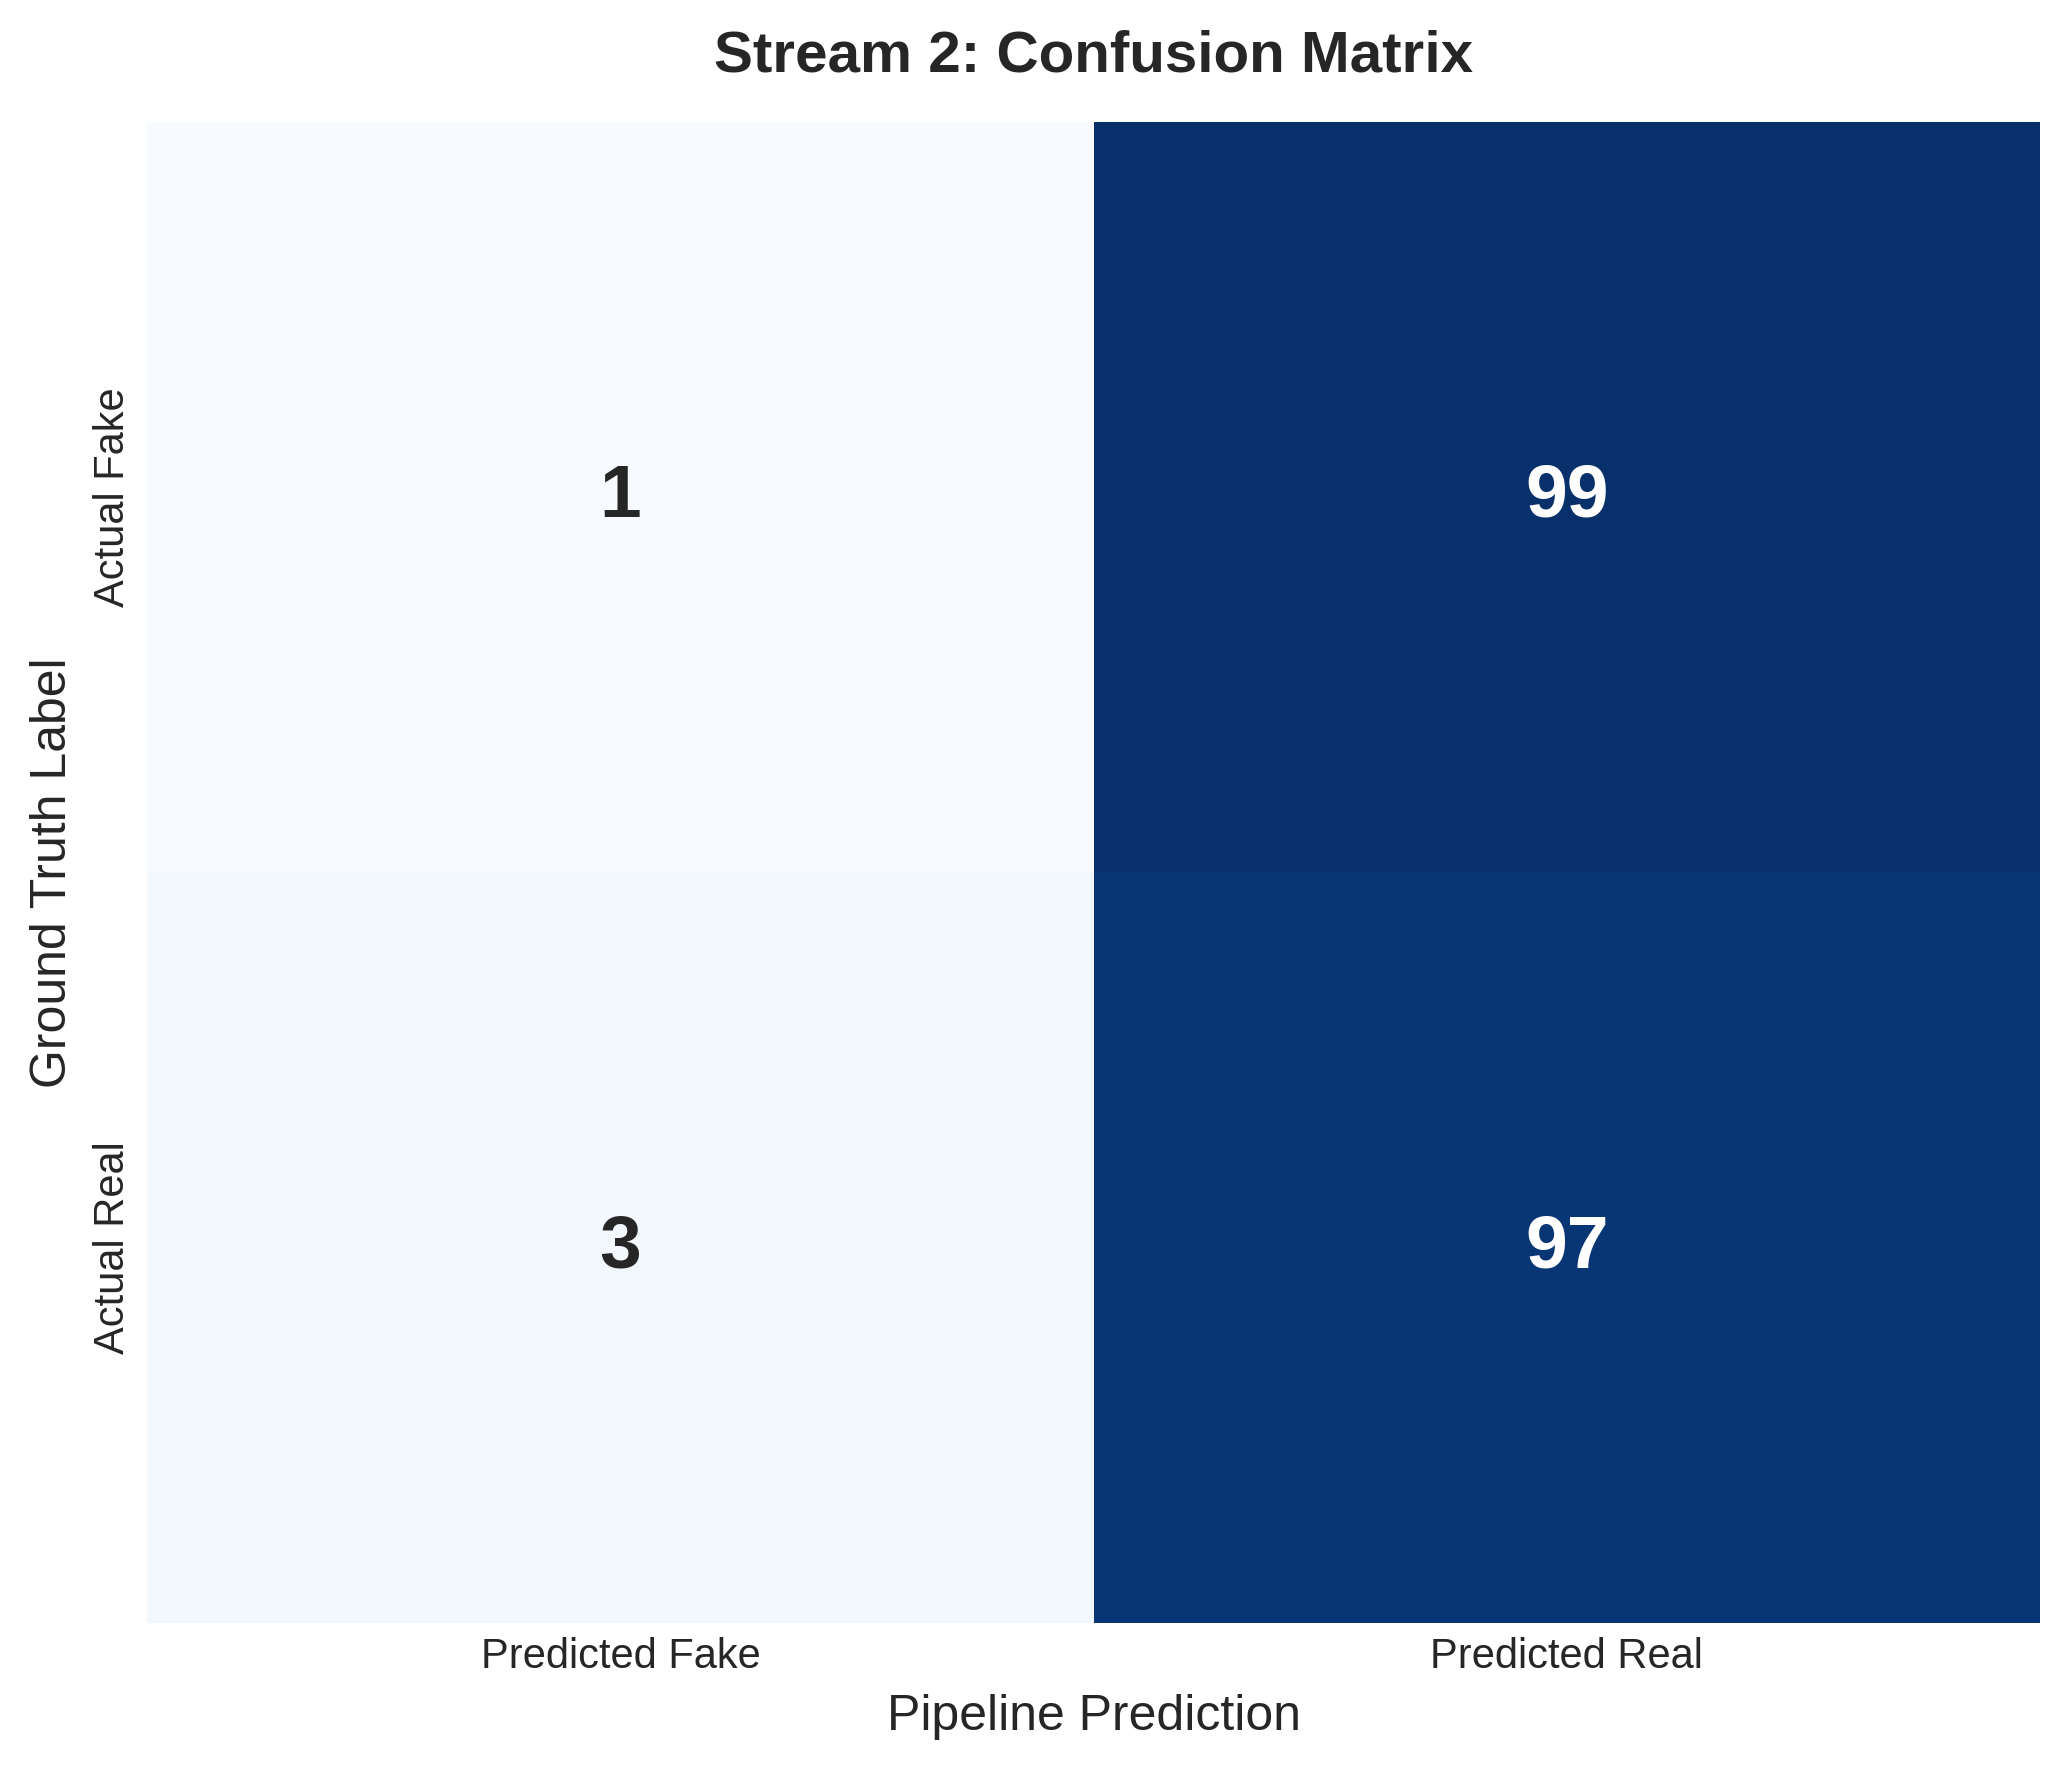

[*] Uploading 'fig_confusion_matrix.png' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'fig_confusion_matrix.png' to storage server!


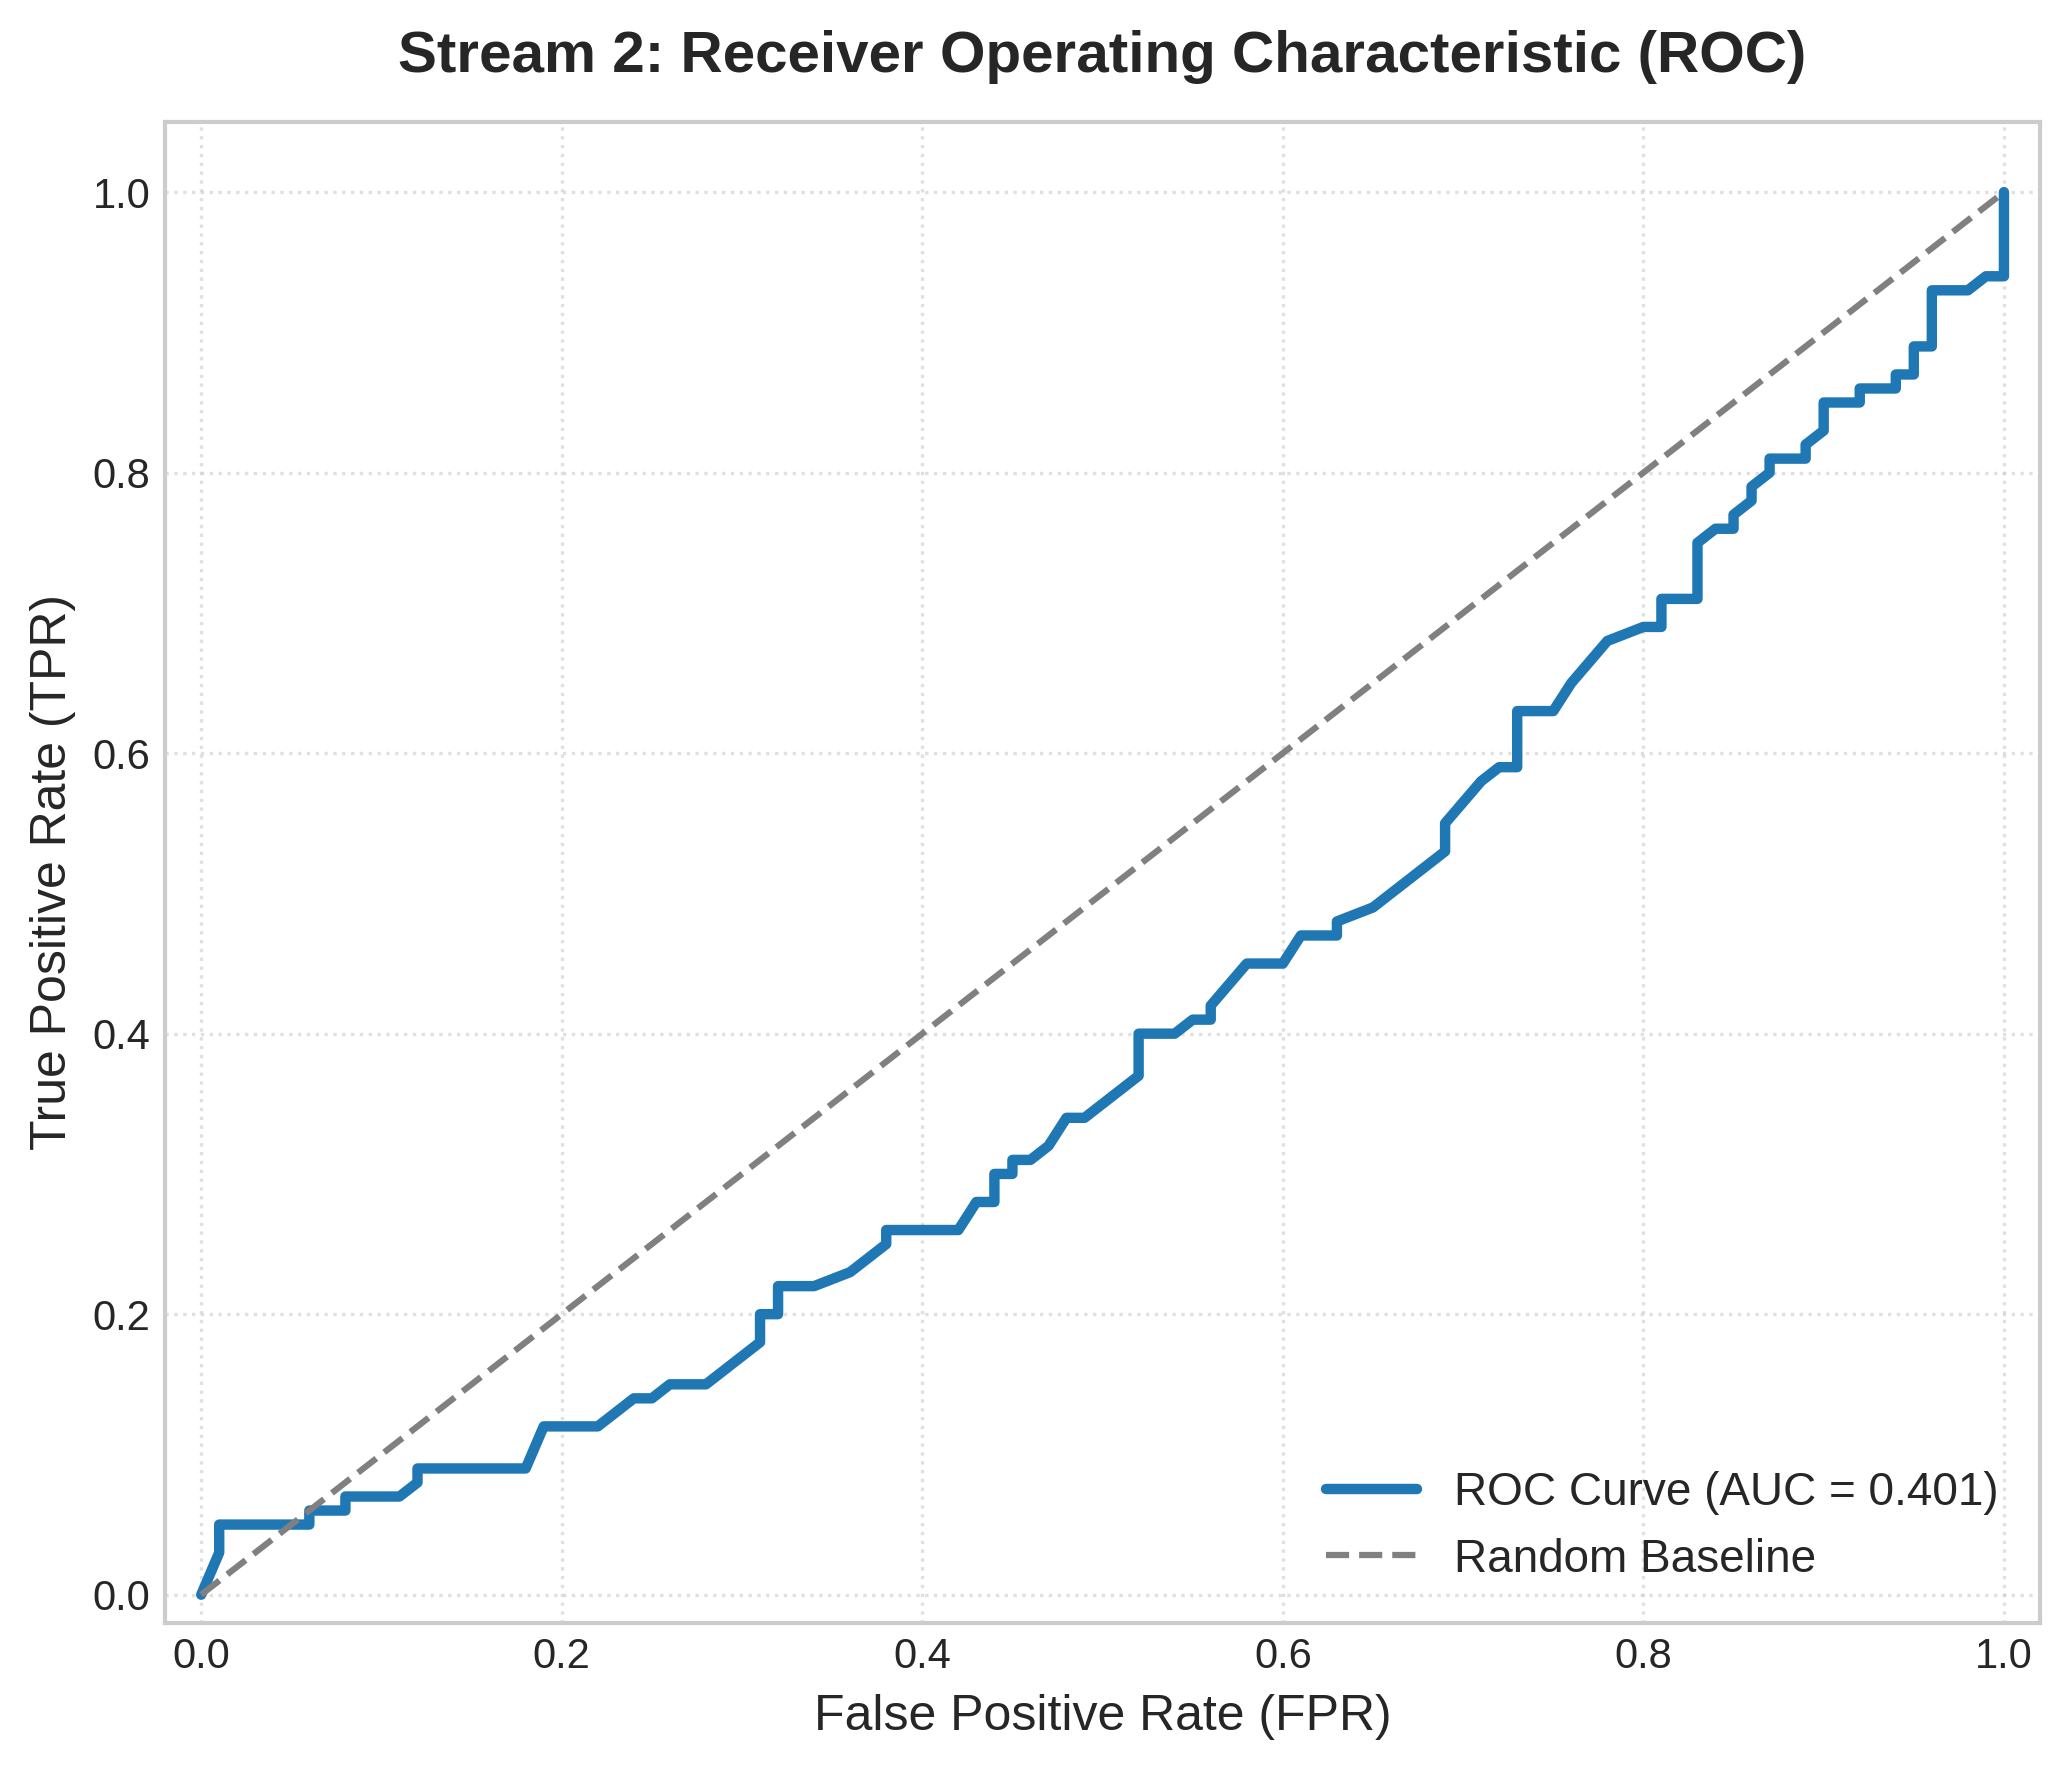

[*] Uploading 'fig_roc_curve.png' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'fig_roc_curve.png' to storage server!


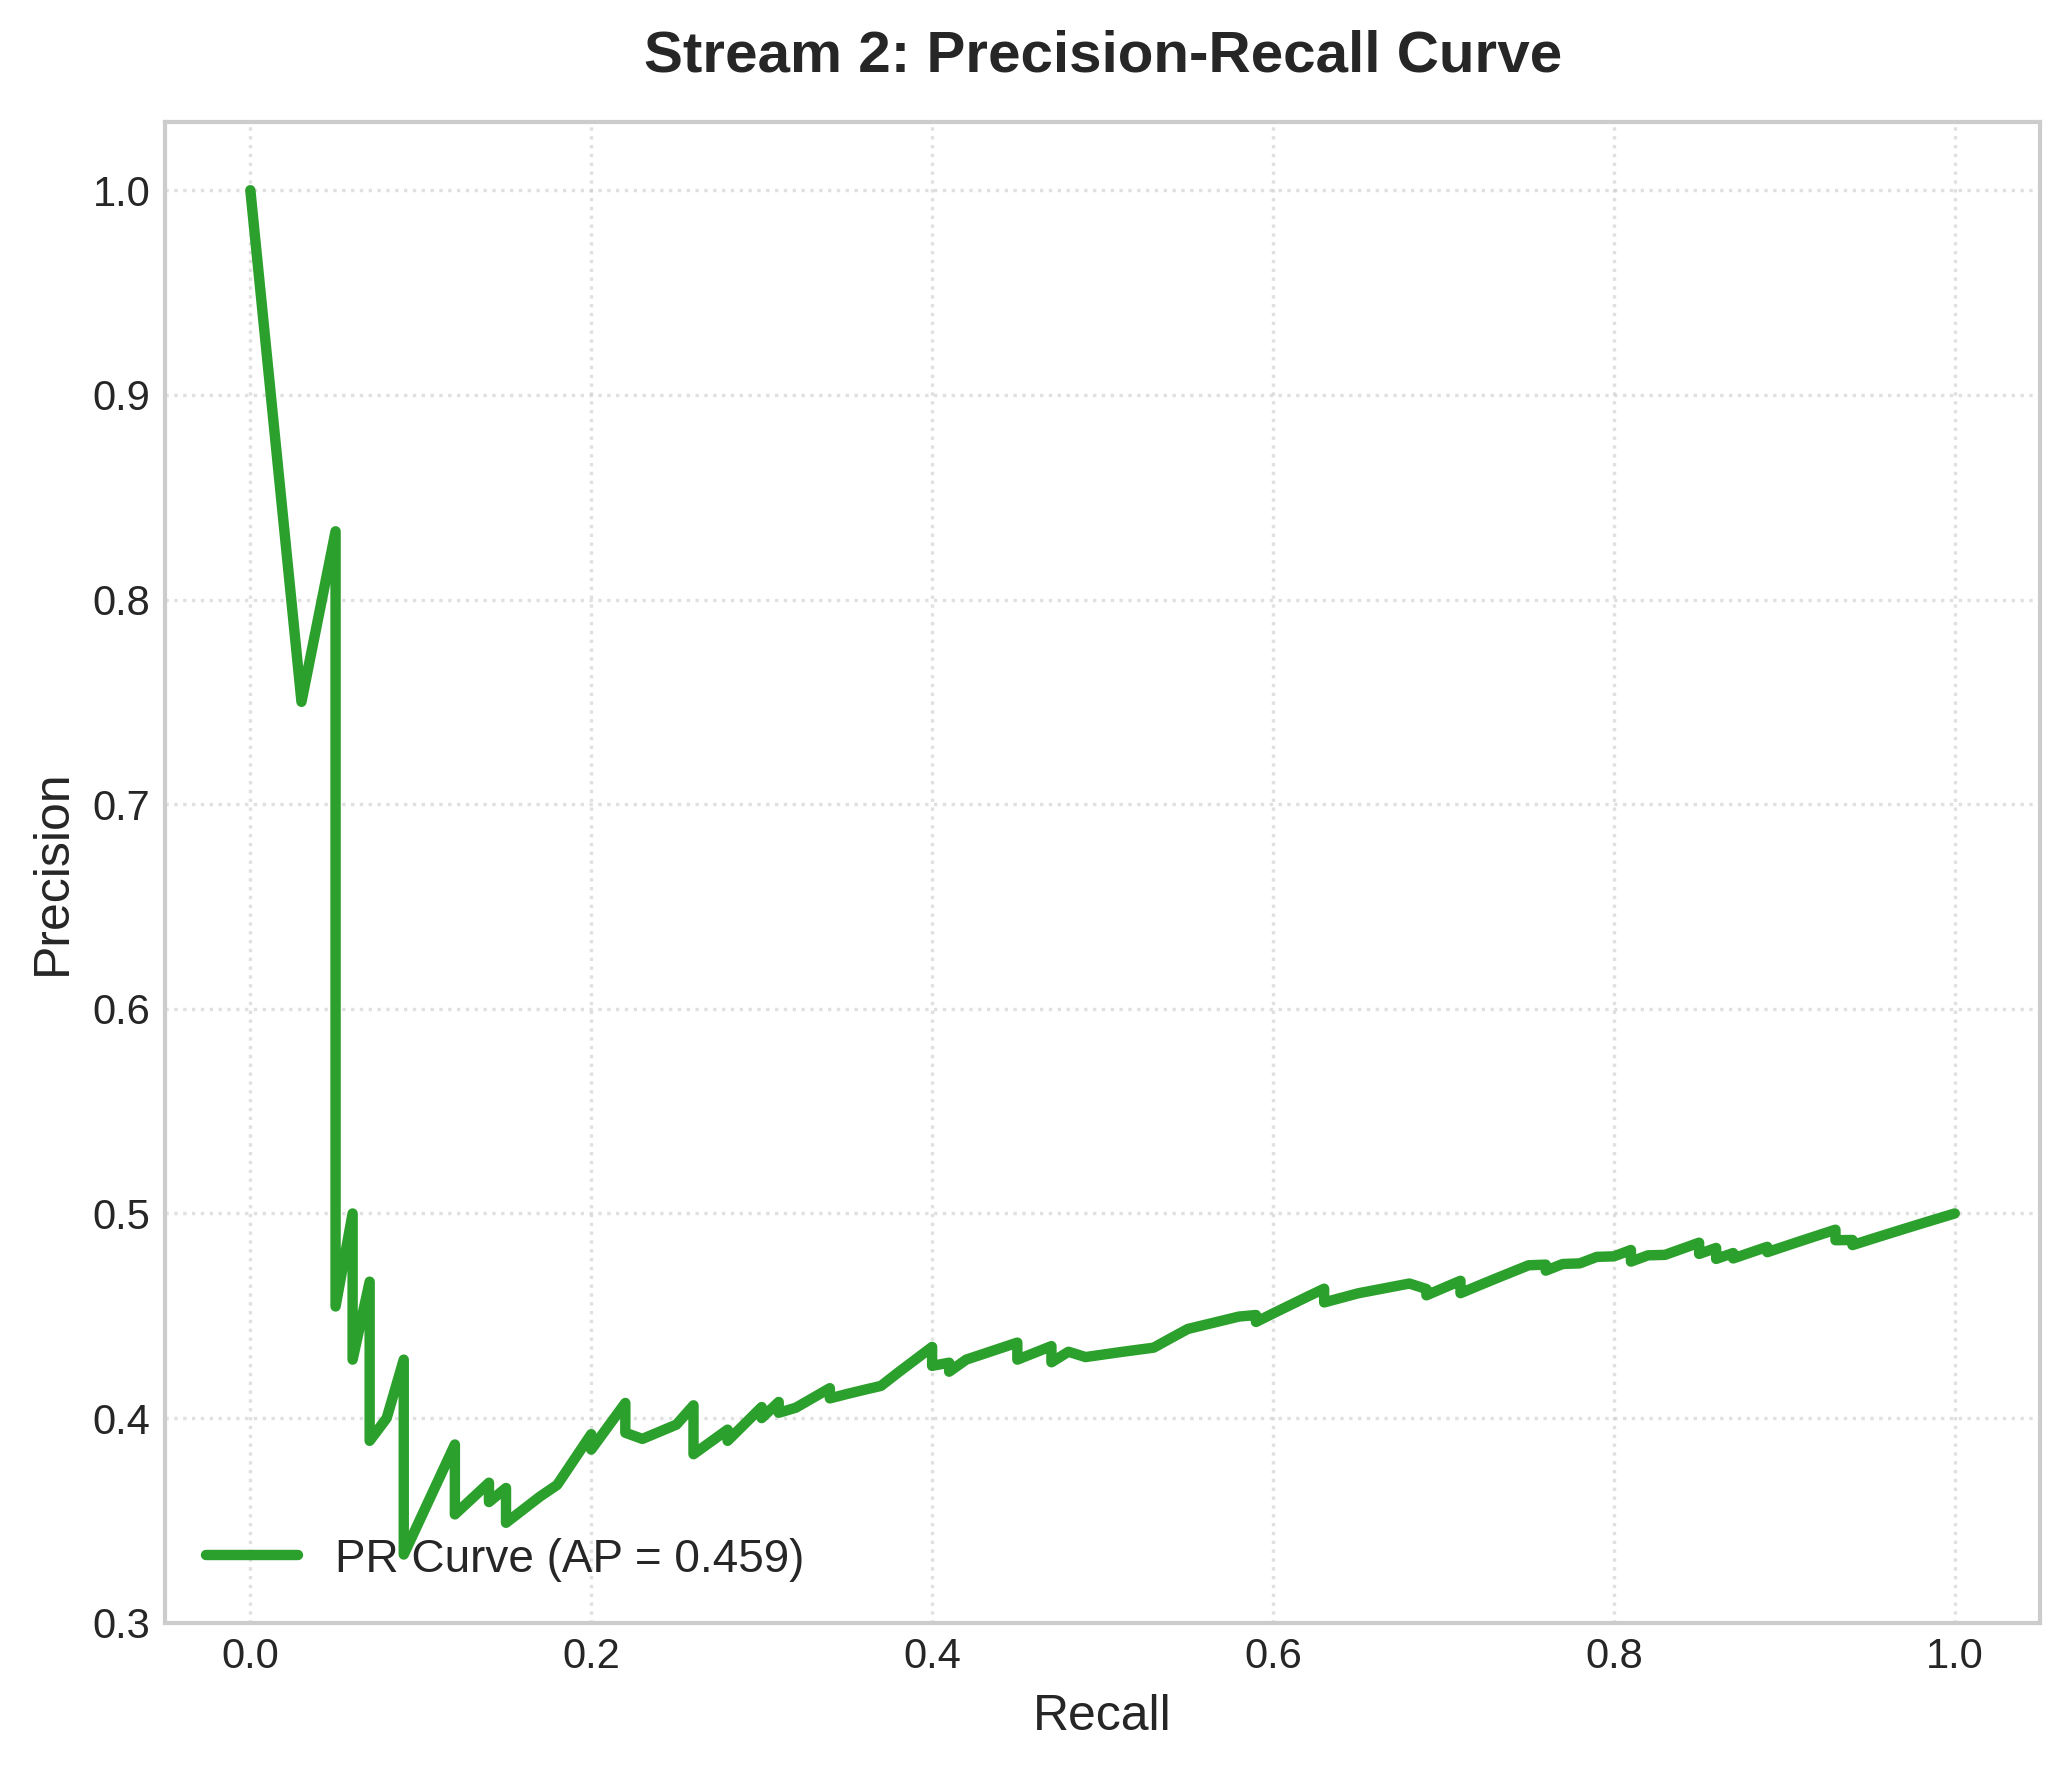

[*] Uploading 'fig_pr_curve.png' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'fig_pr_curve.png' to storage server!


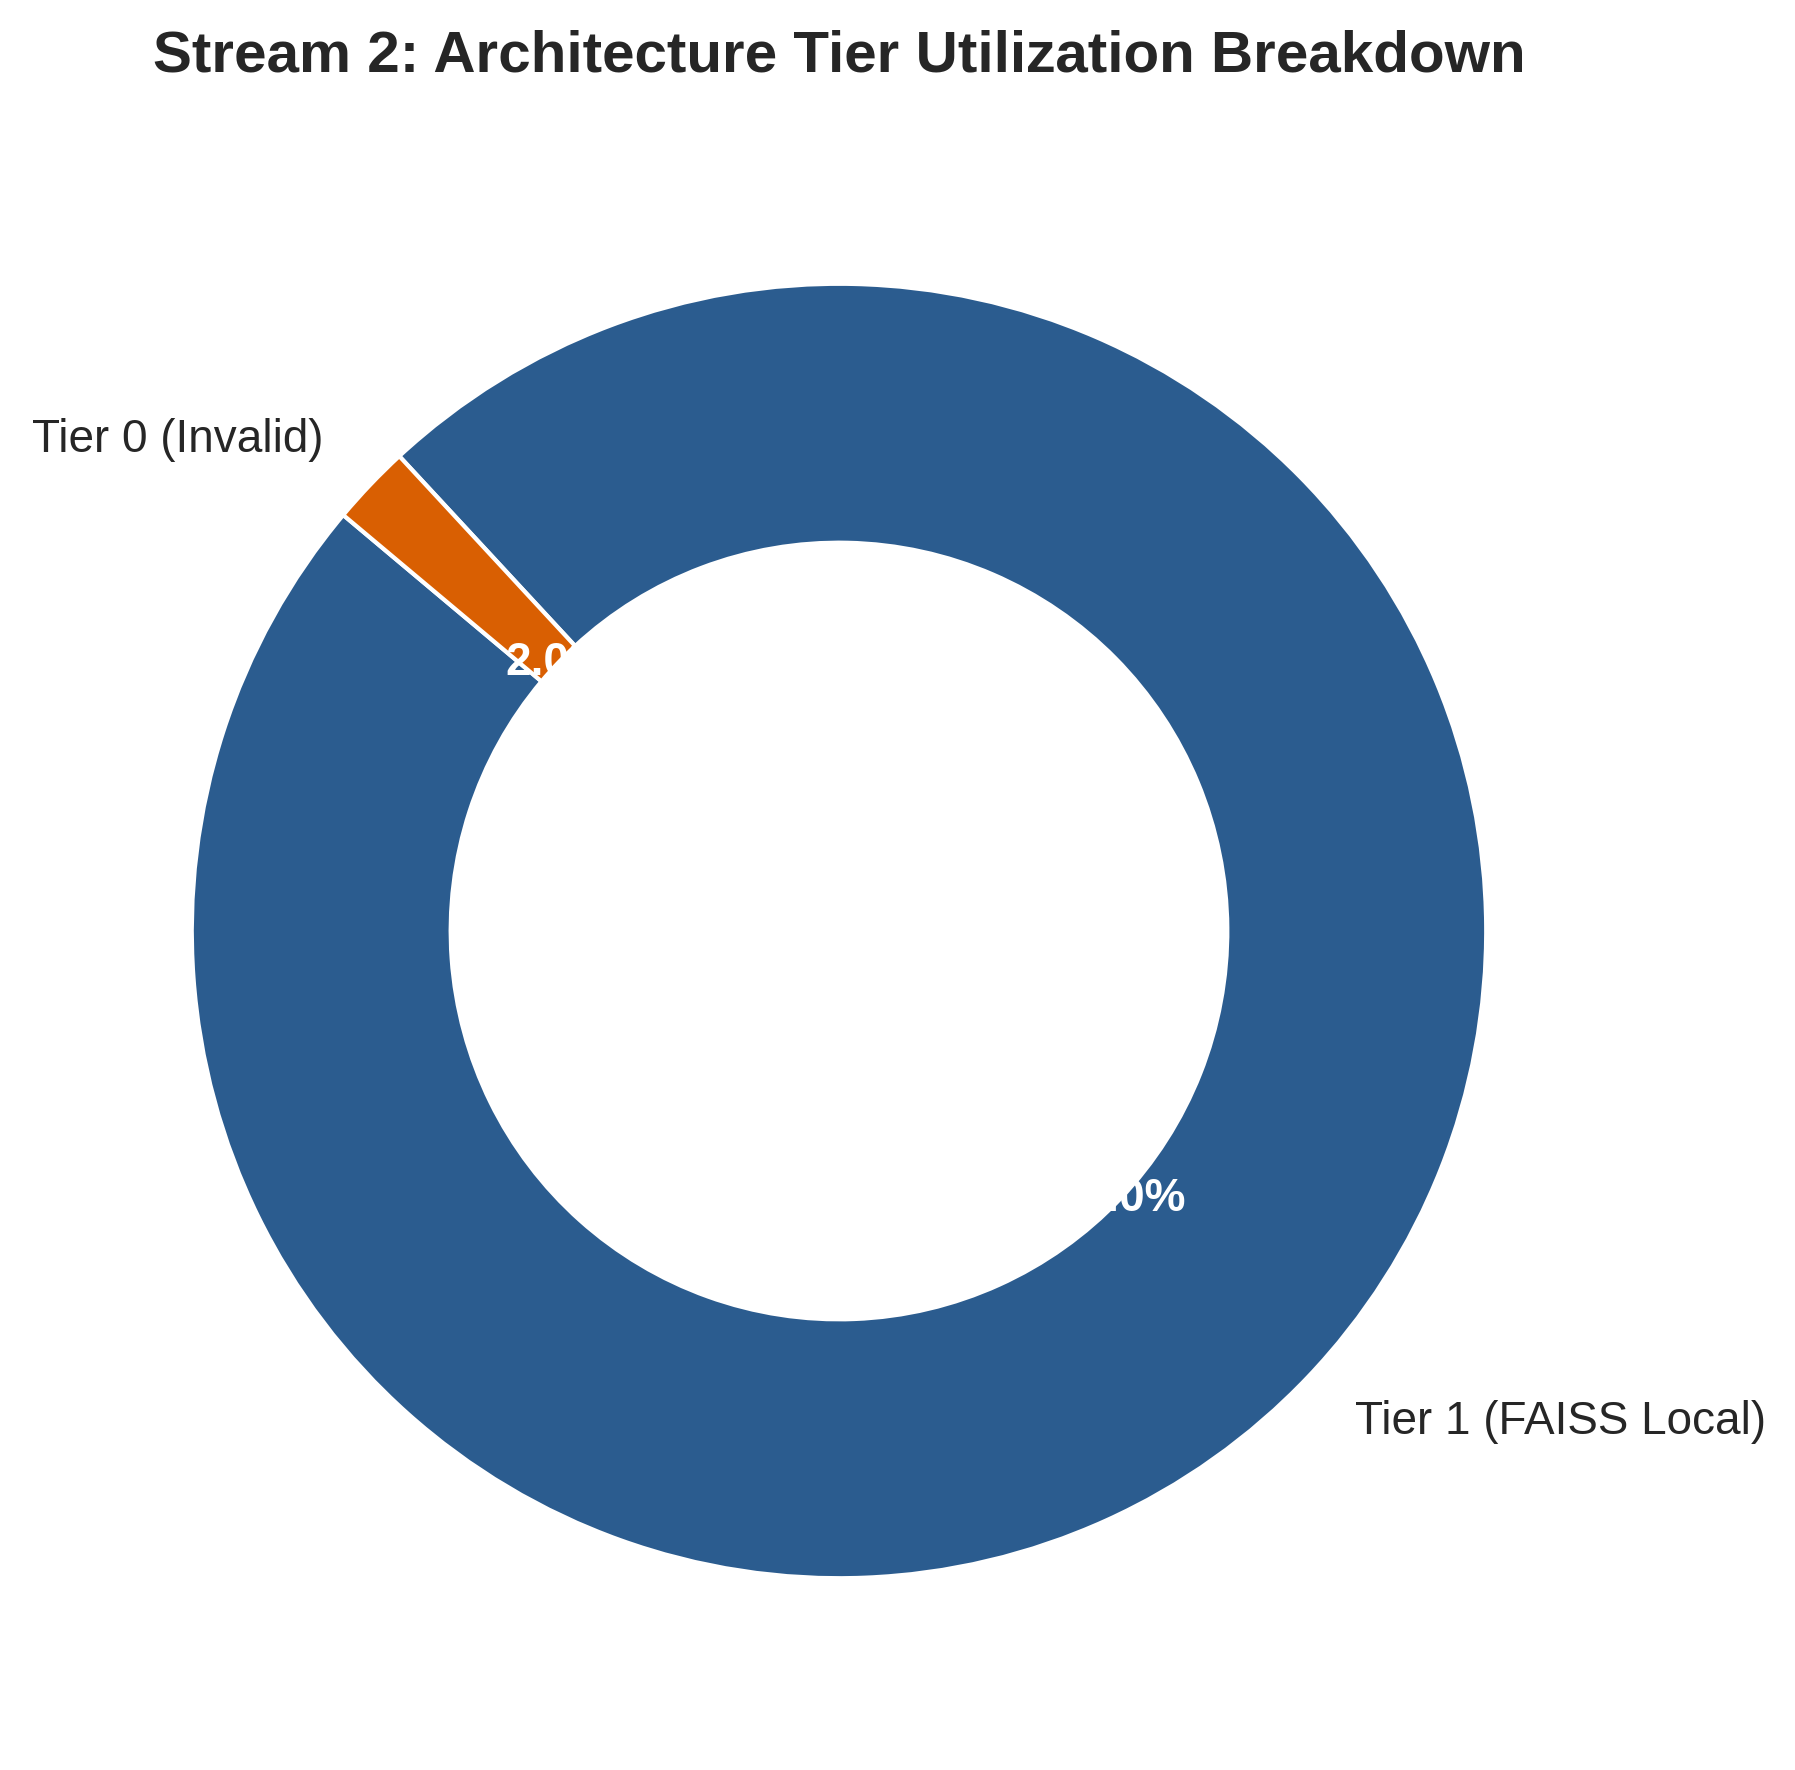

[*] Uploading 'fig_tier_utilization.png' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'fig_tier_utilization.png' to storage server!

[★] All 4 graphs exported separately to '/kaggle/working/performance_visualizations' and synced to remote storage server!


In [13]:
# ==============================================================================
# CELL 7: Export Performance Data & Separate Visualizations
# ==============================================================================
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Set clean aesthetic style for report publication
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig_output_dir = os.path.join(WORKING_DIR, "performance_visualizations")
os.makedirs(fig_output_dir, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. COMPUTE NUMERICAL EVALUATION METRICS
# ------------------------------------------------------------------------------
y_true = df_factual_output['label'].astype(int).values  # 0 = Fake, 1 = Real
y_pred = df_factual_output['is_factual'].astype(int).values
y_scores = df_factual_output['confidence_score'].astype(float).values

# Score polarity adjustment for ROC/PR curves
y_scores_adjusted = np.where(y_pred == 1, y_scores, 1.0 - y_scores)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print("=" * 65)
print("             STREAM 2 FACTUAL VERIFICATION REPORT             ")
print("=" * 65)
print(f"  Overall Classification Accuracy : {acc * 100:.2f}%")
print(f"  Precision                       : {prec:.4f}")
print(f"  Recall                          : {rec:.4f}")
print(f"  F1-Score                        : {f1:.4f}")
print("-" * 65)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Fake (0)', 'Real (1)'], zero_division=0))

# Export Metrics Table to CSV
df_metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "Total Test Samples"],
    "Value": [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4), len(y_true)]
})
METRICS_CSV_PATH = os.path.join(WORKING_DIR, "factual_performance_metrics.csv")
df_metrics_summary.to_csv(METRICS_CSV_PATH, index=False)
push_to_server(METRICS_CSV_PATH)

# ------------------------------------------------------------------------------
# 2. GENERATE AND EXPORT INDIVIDUAL PLOTS
# ------------------------------------------------------------------------------

# --- GRAPH 1: Confusion Matrix ---
plt.figure(figsize=(7, 6), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'],
            annot_kws={"size": 18, "weight": "bold"})
plt.title("Stream 2: Confusion Matrix", fontsize=14, pad=12, fontweight='bold')
plt.ylabel("Ground Truth Label", fontsize=12)
plt.xlabel("Pipeline Prediction", fontsize=12)
plt.tight_layout()
PATH_CM = os.path.join(fig_output_dir, "fig_confusion_matrix.png")
plt.savefig(PATH_CM, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
push_to_server(PATH_CM)


# --- GRAPH 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_scores_adjusted)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6), dpi=300)
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Baseline')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Stream 2: Receiver Operating Characteristic (ROC)', fontsize=14, pad=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
PATH_ROC = os.path.join(fig_output_dir, "fig_roc_curve.png")
plt.savefig(PATH_ROC, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
push_to_server(PATH_ROC)


# --- GRAPH 3: Precision-Recall Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_scores_adjusted)
avg_prec = average_precision_score(y_true, y_scores_adjusted)

plt.figure(figsize=(7, 6), dpi=300)
plt.plot(recall_vals, precision_vals, color='#2ca02c', lw=2.5, label=f'PR Curve (AP = {avg_prec:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Stream 2: Precision-Recall Curve', fontsize=14, pad=12, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
PATH_PR = os.path.join(fig_output_dir, "fig_pr_curve.png")
plt.savefig(PATH_PR, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
push_to_server(PATH_PR)


# --- GRAPH 4: Architecture Tier Utilization ---
plt.figure(figsize=(7, 6), dpi=300)
tier_counts = df_factual_output['tier_used'].value_counts()
colors = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a']

wedges, texts, autotexts = plt.pie(
    tier_counts.values, 
    labels=tier_counts.index, 
    autopct='%1.1f%%',
    startangle=140, 
    colors=colors[:len(tier_counts)],
    textprops=dict(fontsize=11),
    wedgeprops=dict(width=0.4, edgecolor='w') # Donut style
)
plt.setp(autotexts, size=11, weight="bold", color="white")
plt.title('Stream 2: Architecture Tier Utilization Breakdown', fontsize=14, pad=12, fontweight='bold')
plt.tight_layout()
PATH_TIER = os.path.join(fig_output_dir, "fig_tier_utilization.png")
plt.savefig(PATH_TIER, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
push_to_server(PATH_TIER)

print(f"\n[★] All 4 graphs exported separately to '{fig_output_dir}' and synced to remote storage server!")

In [14]:
# ==============================================================================
# CELL 8: Archive All Stream 2 Visual & Performance Artifacts & Upload to Server
# ==============================================================================
import os
import shutil

WORKING_DIR = "/kaggle/working" if os.path.exists("/kaggle") else "./"
BUNDLE_DIR = os.path.join(WORKING_DIR, "stream2_verification_artifacts_bundle")
ZIP_OUTPUT_NAME = os.path.join(WORKING_DIR, "stream2_factual_verification_full_artifacts.zip")

print("[*] Gathering all Stream 2 output artifacts...")
os.makedirs(BUNDLE_DIR, exist_ok=True)

# 1. Copy Detection Output Directory (Cropped component images & metadata JSONs)
DETECTION_OUTPUT_DIR = os.path.join(WORKING_DIR, "detection_output")
if os.path.exists(DETECTION_OUTPUT_DIR):
    bundle_detection_path = os.path.join(BUNDLE_DIR, "detection_output")
    if os.path.exists(bundle_detection_path):
        shutil.rmtree(bundle_detection_path)
    shutil.copytree(DETECTION_OUTPUT_DIR, bundle_detection_path)
    print("  [+] Bundled cropped region images & component metadata")

# 2. Copy Performance Visualizations (Confusion Matrix, ROC, PR Curve, Tier Donut Chart)
PERF_VIS_DIR = os.path.join(WORKING_DIR, "performance_visualizations")
if os.path.exists(PERF_VIS_DIR):
    bundle_vis_path = os.path.join(BUNDLE_DIR, "performance_visualizations")
    if os.path.exists(bundle_vis_path):
        shutil.rmtree(bundle_vis_path)
    shutil.copytree(PERF_VIS_DIR, bundle_vis_path)
    print("  [+] Bundled high-resolution evaluation figures")

# 3. Copy Generated CSV Datasets & Metrics Reports
csv_files_to_bundle = [
    "structured_extracted_claims_ocr.csv",
    "factual_verification_results.csv",
    "factual_performance_metrics.csv"
]

for csv_file in csv_files_to_bundle:
    src_csv = os.path.join(WORKING_DIR, csv_file)
    if os.path.exists(src_csv):
        shutil.copy2(src_csv, os.path.join(BUNDLE_DIR, csv_file))
        print(f"  [+] Bundled CSV report: '{csv_file}'")

# 4. Create Master ZIP Archive
print(f"\n[*] Creating compressed ZIP archive: '{ZIP_OUTPUT_NAME}'...")
if os.path.exists(ZIP_OUTPUT_NAME):
    os.remove(ZIP_OUTPUT_NAME)

shutil.make_archive(ZIP_OUTPUT_NAME.replace('.zip', ''), 'zip', BUNDLE_DIR)
archive_size_mb = os.path.getsize(ZIP_OUTPUT_NAME) / (1024 * 1024)
print(f"[★] Successfully compressed all artifacts ({archive_size_mb:.2f} MB)")

# 5. Push Master ZIP Archive to Server
print("\n[*] Pushing master zip archive to remote storage server...")
push_to_server(ZIP_OUTPUT_NAME)

[*] Gathering all Stream 2 output artifacts...
  [+] Bundled cropped region images & component metadata
  [+] Bundled high-resolution evaluation figures
  [+] Bundled CSV report: 'structured_extracted_claims_ocr.csv'
  [+] Bundled CSV report: 'factual_verification_results.csv'
  [+] Bundled CSV report: 'factual_performance_metrics.csv'

[*] Creating compressed ZIP archive: '/kaggle/working/stream2_factual_verification_full_artifacts.zip'...
[★] Successfully compressed all artifacts (116.29 MB)

[*] Pushing master zip archive to remote storage server...
[*] Uploading 'stream2_factual_verification_full_artifacts.zip' to storage server (https://storage.saifullahmnsur.dev/upload)...
[★] Successfully uploaded 'stream2_factual_verification_full_artifacts.zip' to storage server!
